In [2]:
import matplotlib.pyplot as plt 
import numpy as np
import math
from constants import *
from itertools import cycle, islice


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


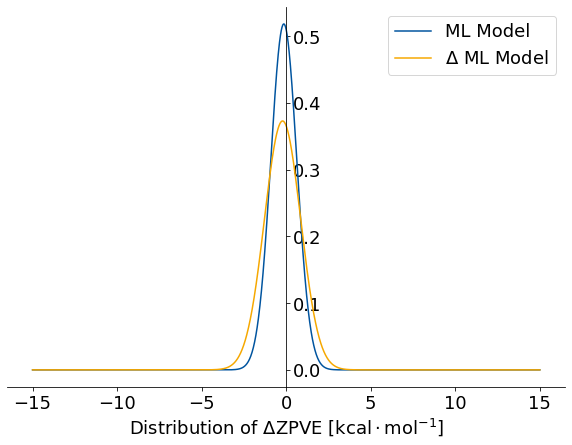

In [7]:
xlabel = [r'Distribution of $\Delta \mathrm{ZPVE}~[\mathrm{kcal \cdot mol^{-1}}]$',r'Distribution of $\Delta \left(\dfrac{\partial ^2 E}{\partial a \partial b}\right)$',
            r'Distribution of $\Delta \left(\dfrac{\partial ^2 E^\mathrm{proj,w}}{\partial a \partial b}\right)$',r'Distribution of $\Delta \left(\dfrac{\partial ^2 E^\mathrm{proj}}{\partial a \partial b}\right)$',
            r'Distribution of $\Delta \tilde{\nu}$ [$\mathrm{kcal \cdot mol^{-1}}$]']
limits = [[-15,15],[-2,2],[-5e-4,5e-4],[-2,2],[-8,8]]

# limits = [[-6.5e-4,6.5e-4]]
par =  ['ZPVE']
# xlabel = [r'Distribution of $\Delta \left(\dfrac{\partial ^2 H^\mathrm{proj,w}}{\partial a \partial b}\right)$']
i = 0
label = [r'ML Model',r'$\Delta$ ML Model']
j = 0
fontsize = 18

plt.style.use('rwth_colors.mplstyle')
def f(x,SD,mean):
    pi = math.pi
    #print(pi)
    #y = np.zeros(len(x))
    y = 1.0/(SD*math.sqrt(2*pi))*np.exp(-0.5*((x-mean)/SD)**2)
    return y
list_plot = []
fig, ax = plt.subplots()
ax.spines['left'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(True)
ax.spines["right"].set_position(("data", 0))

#ax.yaxis.set_ticks_position('right')
#plt.tick_params(axis='y', which='both', labelleft='off', labelright='on')
ax.yaxis.tick_right()
#ax.yaxis.set_ticks_position('both')
D_ZPVE = [list(np.genfromtxt('ZPVE_ML.txt')),list(np.genfromtxt('ZPVE_xTB.txt'))]
D_ZPVE_Delta = [list(np.genfromtxt('ZPVE_ML_Delta.txt')),list(np.genfromtxt('ZPVE_xTB_Delta.txt'))]

for element in [list(D_ZPVE),list(D_ZPVE_Delta)]:


    if par[i] == 'ZPVE':
        array_xtb = ( np.array(element[0]) - np.array(element[1]))*627.5
        arr_i = 0
        array_xtb = list(array_xtb)

        while arr_i < len(element[0]):
            if  element[1][arr_i]*627.5 > 20. or element[1][arr_i] == 0.:
                array_xtb.pop(arr_i)
                element[0].pop(arr_i)
                element[1].pop(arr_i)

            else:
                arr_i += 1
        
    array_xtb = np.array(array_xtb)
    MD = sum(abs(array_xtb.mean()-array_xtb)/len(array_xtb))
    
    dy2 = sum((array_xtb-array_xtb.mean())**2)
    SD = np.sqrt(dy2/len(array_xtb))
    SD = SD
    x = np.linspace(limits[i][0],limits[i][1],2000)
    #print(x)
    mean = array_xtb.mean()
    y = f(x,SD,mean)
    pl, = ax.plot(x,y,label = label[j])
    list_plot.append(pl)
    j+= 1


# plt.xlabel(r'Distribution of $\Delta \tilde{\nu}_\mathrm{n}$ [$\mathrm{cm}^{-1}$]')#[$\mathrm{cm}^{-1}$]' )
# plt.xlabel(r'$\Delta \mathrm{ZPE}~[\mathrm{eV}]$')#\lambda \left(\dfrac{\partial ^2 H^\mathrm{proj}}{\partial a \partial b}\right)$')#$ \Delta \mathrm{ZPE} [\mathrm{eV}]$')#$\dfrac{\partial ^2 H^\mathrm{proj,w}}{\partial a \partial b}$')#\sigma^\mathrm{corr}
if par[i] == 'wn':
    plt.xlabel(xlabel[i],fontsize = fontsize)
else:
    plt.xlabel(xlabel[i],fontsize = fontsize)

savename = f'ErrorDistNonZPE{par[i]}'

plt.setp(ax.yaxis.get_majorticklabels(), rotation=0, ha="left")
plt.legend()
plt.savefig(f'{savename}.png')
plt.savefig(f'{savename}.svg')
plt.savefig(f'{savename}.eps')

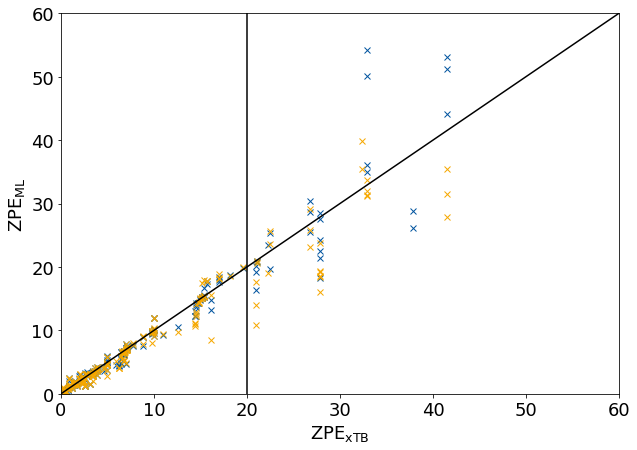

In [25]:
plt.plot(np.array(D_ZPVE[1])*627.5,np.array(D_ZPVE[0])*627.5,'x')

plt.plot(np.array(D_ZPVE_Delta[1])*627.5,np.array(D_ZPVE_Delta[0])*627.5,'x')
#plt.plot(np.array(D_ZPVE_Delta[1])*627.5,np.array(D_ZPVE_Delta[0])*627.5,'x')

plt.plot([0,60],[0,60],'k-')

plt.xlim([0,60])

plt.ylim([0,60])
plt.xlabel(r'ZPE$_\mathrm{xTB}$')
plt.ylabel(r'ZPE$_\mathrm{ML}$')
plt.plot([20,20],[0,100],'k-')
plt.savefig('ZPEvZPE.svg')
plt.savefig('ZPEvZPE.png')

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


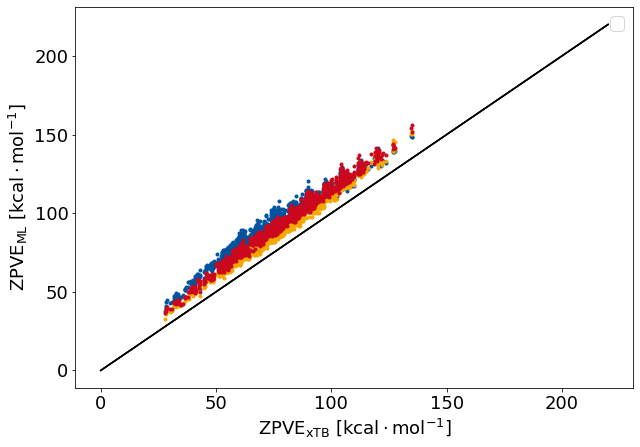

In [16]:
folders = ['plots/gdb7_all_full_features/','plots/gdb7_all/',
'plots/gdb7_all_proj/','plots/gdb7_all_full_features_rfr/','plots/gdb7_all_full_features_rfr2/']
#, 'plots/init_test_set_rot/']#['plots/gdb7_100/','plots/gdb7_100_500estimator/','plots/gdb7_6000_6100/','plots/gdb7_200/']#init_test_set_rot

folders = ['17','18','19']#,'2','3','4','5']
for folder in folders:
    for rnd_state in [46]:#,0,29,56,100]:
        ML = np.genfromtxt(f'plots/{folder}/ZPVE_ML_Delta{rnd_state}.txt')
        xTB =np.genfromtxt(f'plots/{folder}/ZPVE_xTB_Delta{rnd_state}.txt')
        #35 einträge hat das erste train set
        inlier = []
        outlier = []
        #plt.scatter(xTB*627.5,ML*627.5,color=colors[y_pred])
        #plt.plot([0,0],[60,60],'k-')


        #plt.plot(xTB[inlier]*627.5,ML[inlier]*627.5,'.',label='Inlier')
        #plt.plot(xTB[outlier]*627.5,ML[outlier]*627.5,'.',label ='Outlier')


        p = np.polyfit(xTB,ML,1)

        #plt.plot(xTB*627.5,(ML-p[1])*627.5/p[0],'.',label='Adjusted')
        plt.plot(xTB*627.5,(ML)*627.5,'.')

        #p = np.polyfit(xTB,ML,1)
        #ML = (ML-p[1])/p[0]
        #x = np.linspace(0,200,1000)
        #plt.plot(x,p[0]*x+p[1]*627.5,'k-.')
        #plt.plot(xTB*627.5,(ML)*627.5,'.')

        plt.plot([0.,220.],[0.,220.],'k')
        #plt.plot([0.,150.],[2.,152.],'k--')
        #plt.plot([-0.,150.],[-2.,148.],'k--')

        plt.legend()

        plt.xlabel(r'$ \mathrm{ZPVE}_\mathrm{xTB}~[\mathrm{kcal \cdot mol^{-1}}]$')
        plt.ylabel(r'$ \mathrm{ZPVE}_\mathrm{ML}~[\mathrm{kcal \cdot mol^{-1}}]$')

        plt.savefig('ZPEvZPE_example.png')
        plt.savefig('ZPEvZPE_example.svg')


2.6451738010033714 15.274233244955406
925.1759886389392 5342.315819755602


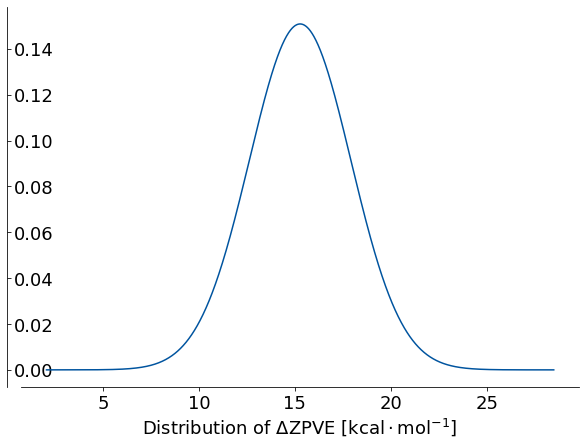

In [17]:
fontsize = 18
limits=[[-15,30]]
plt.style.use('rwth_colors.mplstyle')
def f(x,SD,mean):
    pi = math.pi
    #print(pi)
    #y = np.zeros(len(x))
    y = 1.0/(SD*math.sqrt(2*pi))*np.exp(-0.5*((x-mean)/SD)**2)
    return y
list_plot = []
fig, ax = plt.subplots()
ax.spines['left'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(True)
ax.spines["right"].set_position(("data", 0))
ax.yaxis.tick_right()
par = ['ZPVE']
xlabel = [r'Distribution of $\Delta \mathrm{ZPVE}~[\mathrm{kcal \cdot mol^{-1}}]$']
label = [r'Inliers',r'Inliers + Outliers']

j = 0
i = 0
for element in [list([list(ML),list(xTB)])]:

    if par[i] == 'ZPVE':
        array_xtb = ( np.array(element[0]) - np.array(element[1]))*627.5
        arr_i = 0
        array_xtb = list(array_xtb)

        while arr_i < len(element[0]):
            if  element[1][arr_i]*627.5 > 1000. or element[1][arr_i] == 0.:
                array_xtb.pop(arr_i)
                element[0].pop(arr_i)
                element[1].pop(arr_i)

            else:
                arr_i += 1

    array_xtb = np.array(array_xtb)
    MD = sum(abs(array_xtb.mean()-array_xtb)/len(array_xtb))

    mean =array_xtb.mean()
    
    dy2 = sum((array_xtb-array_xtb.mean())**2)
    SD = np.sqrt(dy2/len(array_xtb))
    SD = SD

    limits = [[mean-5*SD,mean+5*SD]]

    x = np.linspace(limits[i][0],limits[i][1],2000)
    print(SD,mean)
    print(SD*349.76,mean*349.76)

    mean = array_xtb.mean()
    y = f(x,SD,mean)
    pl, = ax.plot(x,y,label = label[j])
    list_plot.append(pl)
    j+= 1

if par[i] == 'wn':
    plt.xlabel(xlabel[i],fontsize = fontsize)
else:
    plt.xlabel(xlabel[i],fontsize = fontsize)

savename = f'ErrorDistNonZPE{par[i]}'
plt.setp(ax.yaxis.get_majorticklabels(), rotation=0, ha="left")

#plt.legend()
plt.xlabel(r'Distribution of $\Delta \mathrm{ZPVE}~[\mathrm{kcal \cdot mol^{-1}}]$')

plt.savefig('ErrorDist_example.png')
plt.savefig('ErrorDist_example.svg')



In [5]:
import numpy as np
import pickle
import pandas as pd

with open('plots/15/Target_Vector_Hetero','rb') as f:
    systems = pickle.load(f)



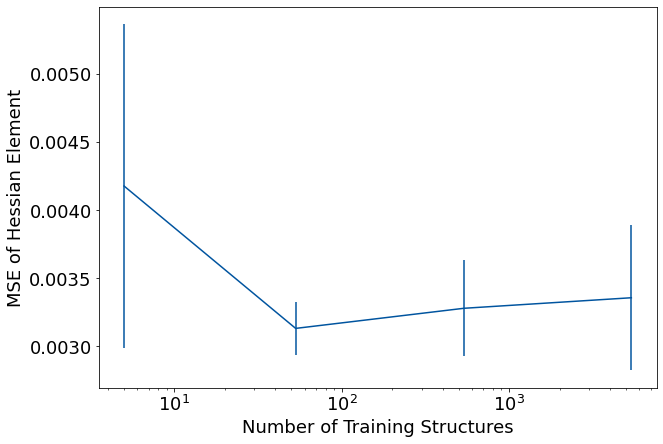

In [25]:
import numpy as np
import pickle
import pandas as pd
import matplotlib.pyplot as plt

md = []
std = []
data = [5371,537,53,5]
folders = ['13','14','15','16']
for folder in folders:
    MSE = np.loadtxt(f'plots/{folder}/MSE_Hessian_Elements.txt')
    MD = np.mean(MSE)
    STD = np.std(MSE)
    md.append(MD)
    std.append(STD)

plt.errorbar(data,md,std)
plt.xlabel('Number of Training Structures')
plt.ylabel('MSE of Hessian Elements')

plt.xscale('log')